# Notebook 2 — Gradient-Boosted Decision Stumps

**MediShift · Forecasting Engine, Model 2 of 3**

Ridge Regression (Notebook 1) assumes patient inflow is a straight-line
combination of features. That assumption breaks whenever two features interact
— for instance, rain might depress patient inflow far more on a Monday than a
Sunday, an effect no single linear coefficient can express. This notebook
implements MediShift's second forecasting model, described in report
**Section 2.3**: an additive ensemble of **decision stumps** (the simplest
possible tree — a single yes/no split on one feature), fitted the same way
libraries like XGBoost fit gradient-boosted trees, but deliberately simplified
to run in well under a second on a phone.

**What this notebook covers**

1. Load the shift dataset and build the (slightly different) feature set the report specifies for a tree-based model
2. Derive the additive, residual-correcting boosting update rule from first principles
3. Implement a single decision stump — the weighted greedy split search — from scratch
4. Run 30 rounds of boosting and watch the training error fall round by round
5. Evaluate on the same held-out shifts as Notebook 1
6. Inspect which features the model actually chose to split on, and why
7. Save this model's held-out predictions for the ensemble notebook (Notebook 4)

## 1. Setup & Data Loading

In [1]:
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.edgecolor"] = "#52514E"
plt.rcParams["axes.labelcolor"] = "#0B0B0B"
plt.rcParams["text.color"] = "#0B0B0B"
plt.rcParams["xtick.color"] = "#52514E"
plt.rcParams["ytick.color"] = "#52514E"

C = {
    "blue": "#2A78D6", "orange": "#EB6834", "aqua": "#1BAF7A",
    "yellow": "#EDA100", "violet": "#4A3AA7", "ink": "#0B0B0B",
    "muted": "#898781", "hair": "#E1E0D9", "surface": "#FCFCFB",
}
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

with open("shift_dataset_3years.json") as f:
    records = json.load(f)

df = pd.DataFrame(records)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "id"]).reset_index(drop=True)
print(f"Records: {len(df):,}  |  Date range: {df['date'].min().date()} -> {df['date'].max().date()}")

Records: 3,291  |  Date range: 2023-08-04 -> 2026-08-04


## 2. Feature Engineering

Per report Table 1.1, the boosted-stumps model uses the same feature family as
Ridge Regression *minus the intercept* (a split-based model has no use for a
constant column — a stump can always reproduce a constant by splitting on
nothing meaningfully, so an intercept only wastes a round) *plus a cyclic
month encoding*, so that December and January read as calendar neighbours
rather than as the numbers 12 and 1.

In [2]:
df["weekday"] = df["date"].dt.weekday

df["rolling_avg_7"] = df["patient_inflow"].shift(1).rolling(7, min_periods=1).mean()
df["rolling_avg_7"] = df["rolling_avg_7"].fillna(df["patient_inflow"].mean())

df["day_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)   # boosting-only feature

df["shift_morning"]   = (df["shift_type"] == "Morning").astype(float)
df["shift_evening"]   = (df["shift_type"] == "Evening").astype(float)
df["weather_rain"]    = (df["weather"] == "Rain").astype(float)
df["weather_extreme"] = (df["weather"] == "Extreme Heat").astype(float)
df["holiday"]         = df["is_holiday"].astype(float)
df["local_event"]     = df["is_local_event"].astype(float)

BOOST_FEATURES = [
    "shift_morning", "shift_evening",
    "weather_rain", "weather_extreme",
    "holiday", "local_event",
    "rolling_avg_7",
    "day_sin", "day_cos", "month_cos",
]

X_all = df[BOOST_FEATURES].values
y_all = df["patient_inflow"].values.astype(float)

N = len(df)
SPLIT = int(N * 0.8)   # identical split to Notebook 1, so results are comparable
X_train, y_train = X_all[:SPLIT], y_all[:SPLIT]
X_test,  y_test  = X_all[SPLIT:], y_all[SPLIT:]
dates_test = df["date"].values[SPLIT:]

print(f"Training records: {SPLIT:,}   Held-out records: {N - SPLIT:,}")
print(f"Features ({len(BOOST_FEATURES)}): {BOOST_FEATURES}")

Training records: 2,632   Held-out records: 659
Features (10): ['shift_morning', 'shift_evening', 'weather_rain', 'weather_extreme', 'holiday', 'local_event', 'rolling_avg_7', 'day_sin', 'day_cos', 'month_cos']


## 3. Deriving the Boosting Update Rule

### 3.1 The idea: fit residuals, not the target

Instead of fitting one model to the raw target $y$, gradient boosting fits a
**sequence** of small models, each one trained to correct the mistakes left
behind by everything before it. Start from a single constant baseline —
MediShift uses the recency-weighted mean of the training targets, $F_0$ (the
same recency weights $w_i$ from Notebook 1, Section 3.4, reused here for
consistency with the rest of the forecasting engine):

$$
F_0(\mathbf{x}) = \frac{\sum_i w_i\, y_i}{\sum_i w_i}.
$$

At round $m$, compute the **residuals** — how wrong the current ensemble
$F_{m-1}$ still is on every training record:

$$
r_i = y_i - F_{m-1}(\mathbf{x}_i).
$$

Fit a small model $h_m$ to predict these residuals (details in Section 3.2
below), then add it back into the ensemble at a small **learning rate**
$\eta=0.1$, so no single round can overcorrect:

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta\, h_m(\mathbf{x}).
\tag{2.4}
$$

Thirty rounds of this ($m = 1,\dots,30$) is the whole algorithm. It is the same
additive, residual-correcting idea libraries like XGBoost use — MediShift's
version trades XGBoost's deeper trees and more sophisticated split criterion
for the simplest possible weak learner, in exchange for a model that refits
on a phone in a fraction of a second.

### 3.2 The weak learner: a decision stump

A **decision stump** is a tree with exactly one split: pick a feature $j$ and a
threshold $t$, and partition the training data into two groups,
$\{\mathbf{x}_i : x_{i,j}\le t\}$ and $\{\mathbf{x}_i : x_{i,j} > t\}$. Each
group is assigned its own constant prediction — the (weighted) mean residual
of the records that land in it. Fitting a stump to residuals $r_i$ means
choosing $(j, t)$ to minimise the total weighted squared error left over
*after* the split:

$$
(j^\*, t^\*) = \operatorname*{arg\,min}_{j,\,t}\;
  \sum_{i:\,x_{i,j}\le t} w_i\big(r_i - \bar r_{\text{left}}\big)^2
  \;+\;
  \sum_{i:\,x_{i,j} > t} w_i\big(r_i - \bar r_{\text{right}}\big)^2,
$$

where $\bar r_{\text{left}}$ and $\bar r_{\text{right}}$ are the weighted mean
residual on each side of the split. This is a small combinatorial search — try
every feature, and for each feature try every candidate threshold — but with
only 10 features and a few dozen candidate thresholds each, it is cheap enough
to repeat 30 times on-device.

In [3]:
def weighted_mean(values, weights):
    return np.sum(values * weights) / np.sum(weights)


def fit_stump(X, residuals, weights, max_thresholds=40):
    '''Exhaustive search for the single (feature, threshold) split that
    minimises weighted SSE of the residuals on each side -- Section 3.2.
    Returns (sse, feature_index, threshold, left_value, right_value).
    '''
    n, p = X.shape
    best = None
    for j in range(p):
        col = X[:, j]
        candidates = np.unique(col)
        if len(candidates) > max_thresholds:
            qs = np.quantile(col, np.linspace(0, 1, max_thresholds))
            candidates = np.unique(qs)

        for t in candidates:
            left = col <= t
            if 0 < left.sum() < n:
                right = ~left
                w_l, w_r = weights[left], weights[right]
                mean_l = weighted_mean(residuals[left], w_l)
                mean_r = weighted_mean(residuals[right], w_r)
                sse = (np.sum(w_l * (residuals[left] - mean_l) ** 2)
                       + np.sum(w_r * (residuals[right] - mean_r) ** 2))
                if best is None or sse < best[0]:
                    best = (sse, j, t, mean_l, mean_r)
    return best


def stump_predict(X, feature, threshold, left_value, right_value):
    return np.where(X[:, feature] <= threshold, left_value, right_value)

## 4. Recency Weights (Same Scheme as Notebook 1)

The boosted-stumps model reuses the exact recency-weighting scheme from
Section 1.5 — a record's influence halves roughly every 90 shift records
(30 days) — both for the initial baseline $F_0$ and for every stump's split
search.

In [4]:
def recency_weights(n_train, half_life_records=90):
    d = 0.5 ** (1.0 / half_life_records)
    i = np.arange(n_train)
    return d ** (n_train - 1 - i)

weights = recency_weights(len(y_train))

## 5. Run 30 Rounds of Boosting

In [5]:
ETA = 0.1
N_ROUNDS = 30

F0 = weighted_mean(y_train, weights)
pred_train = np.full(len(y_train), F0)
pred_test  = np.full(len(y_test),  F0)

stumps = []
train_mae_curve, test_mae_curve = [], []

t0 = time.time()
for m in range(1, N_ROUNDS + 1):
    residual = y_train - pred_train
    sse, j, t, left_val, right_val = fit_stump(X_train, residual, weights)
    stumps.append((j, t, left_val, right_val))

    pred_train = pred_train + ETA * stump_predict(X_train, j, t, left_val, right_val)
    pred_test  = pred_test  + ETA * stump_predict(X_test,  j, t, left_val, right_val)

    train_mae_curve.append(np.mean(np.abs(y_train - pred_train)))
    test_mae_curve.append(np.mean(np.abs(y_test - pred_test)))

elapsed = time.time() - t0
print(f"Fitted {N_ROUNDS} rounds in {elapsed:.3f}s on {len(y_train):,} training records "
      f"({len(BOOST_FEATURES)} features) -- comfortably under a second, as the report requires.")

Fitted 30 rounds in 0.234s on 2,632 training records (10 features) -- comfortably under a second, as the report requires.


## 6. Evaluate on Held-Out Shifts

In [6]:
def evaluate(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

metrics_train = evaluate(y_train, pred_train)
metrics_test  = evaluate(y_test,  pred_test)
metrics_df = pd.DataFrame([metrics_train, metrics_test], index=["Train (fitted)", "Held-out (test)"])
metrics_df

,MAE,RMSE,R2
Train (fitted),106.93,129.42,0.82
Held-out (test),116.38,141.02,0.81


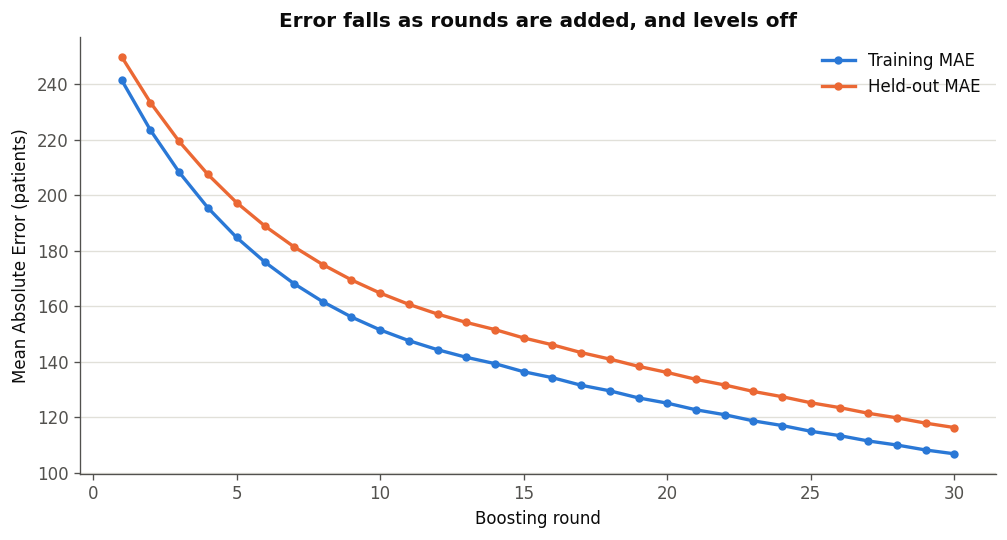

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
rounds = np.arange(1, N_ROUNDS + 1)
ax.plot(rounds, train_mae_curve, color=C["blue"], lw=2, marker="o", ms=4, label="Training MAE")
ax.plot(rounds, test_mae_curve, color=C["orange"], lw=2, marker="o", ms=4, label="Held-out MAE")
ax.set_xlabel("Boosting round")
ax.set_ylabel("Mean Absolute Error (patients)")
ax.set_title("Error falls as rounds are added, and levels off", fontweight="bold", color=C["ink"])
ax.legend(frameon=False)
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Reading the chart.** Both curves fall steeply over the first handful of
rounds — each new stump is still correcting a large, easy-to-find pattern
(mostly which shift type it is) — then flatten out as the easy signal is used
up and later rounds are left refining smaller effects. The held-out curve
tracking the training curve closely, rather than diverging upward, is a good
sign: with only 30 rounds and single-split stumps, this model is nowhere near
complex enough to overfit this dataset.

## 7. Which Features Did the Model Actually Use?

Every stump picks exactly one feature to split on. Counting those choices
across all 30 rounds shows what the model found useful, in order of how often
it returned to each signal.

In [8]:
import collections
feature_counts = collections.Counter(BOOST_FEATURES[s[0]] for s in stumps)
usage = pd.DataFrame({
    "feature": list(feature_counts.keys()),
    "rounds_used": list(feature_counts.values()),
}).sort_values("rounds_used", ascending=False).reset_index(drop=True)
usage["share_of_30_rounds"] = (usage["rounds_used"] / N_ROUNDS * 100).round(1)
usage

,feature,rounds_used,share_of_30_rounds
0,shift_morning,22,73.30
1,shift_evening,8,26.70


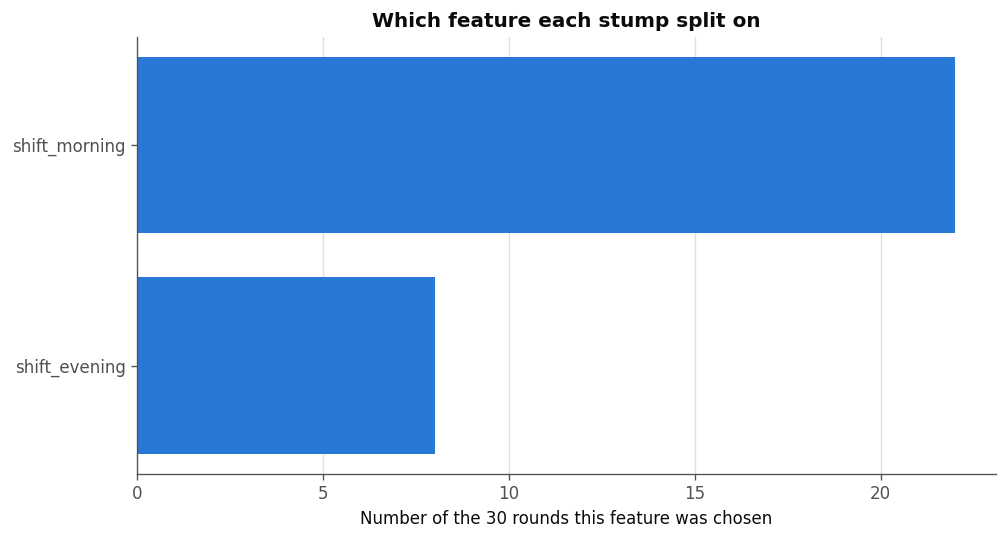

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
bars = ax.barh(usage["feature"][::-1], usage["rounds_used"][::-1], color=C["blue"])
ax.set_xlabel("Number of the 30 rounds this feature was chosen")
ax.set_title("Which feature each stump split on", fontweight="bold", color=C["ink"])
ax.grid(axis="x", color=C["hair"])
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The shift-type indicators dominate, exactly as in Ridge Regression's
coefficient table (Notebook 1) — they are by far the strongest driver of
patient inflow in this dataset, so a greedy split search keeps returning to
them before spending rounds on smaller effects like weather or the rolling
average. This is an honest limitation of a 30-round, single-split ensemble: a
feature with a small but real effect (`rolling_avg_7`, a *continuous* signal
that a single split can only partially capture) may get little attention while
a large categorical effect keeps winning the greedy search. This is precisely
why MediShift does not rely on the boosted-stumps model alone — Notebook 4
blends it with Ridge Regression and Holt-Winters so that no single model's
blind spot becomes the system's blind spot.

## 8. Visualising the Fit

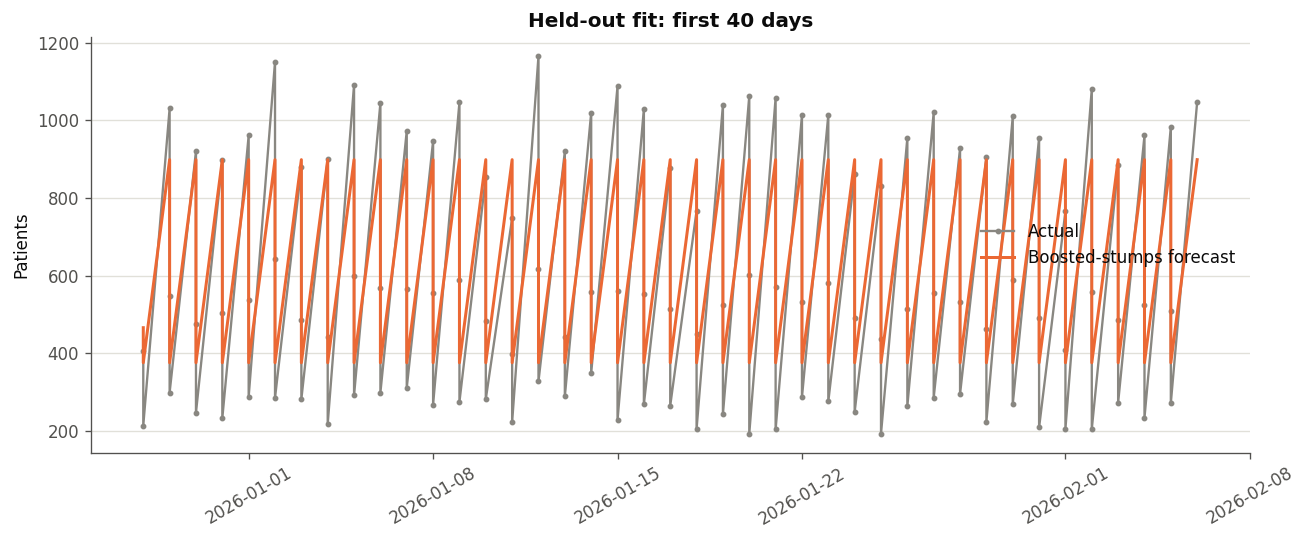

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.6))
window = slice(0, 120)
ax.plot(dates_test[window], y_test[window], color=C["muted"], lw=1.4, label="Actual", marker="o", ms=2.5)
ax.plot(dates_test[window], pred_test[window], color=C["orange"], lw=1.8, label="Boosted-stumps forecast")
ax.set_title("Held-out fit: first 40 days", fontweight="bold", color=C["ink"])
ax.set_ylabel("Patients")
ax.legend(frameon=False)
ax.grid(axis="y", color=C["hair"])
ax.set_axisbelow(True)
for label in ax.get_xticklabels():
    label.set_rotation(30)
plt.tight_layout()
plt.show()

## 9. Save Predictions for the Ensemble Notebook

In [11]:
import os
os.makedirs("artifacts", exist_ok=True)

out = pd.DataFrame({
    "date": pd.to_datetime(dates_test),
    "shift_type": df["shift_type"].values[SPLIT:],
    "y_true": y_test,
    "y_pred_boosted": pred_test,
})
out.to_csv("artifacts/boosted_predictions.csv", index=False)

print(f"Saved {len(out):,} held-out predictions to artifacts/boosted_predictions.csv")
print(f"Held-out MAE for this model (used as the ensemble weight input in Notebook 4): {metrics_test['MAE']:.3f}")
out.head()

Saved 659 held-out predictions to artifacts/boosted_predictions.csv
Held-out MAE for this model (used as the ensemble weight input in Notebook 4): 116.383


,date,shift_type,y_true,y_pred_boosted
0,2025-12-28,Evening,406.00,465.94
1,2025-12-28,Night,214.00,375.69
2,2025-12-29,Morning,"1,031.00",898.73
3,2025-12-29,Evening,548.00,465.94
4,2025-12-29,Night,299.00,375.69


## Summary

| | |
|---|---|
| **Model** | Gradient-boosted decision stumps, from scratch |
| **Features** | 10 (Table 1.1, boosting variant) |
| **Rounds / learning rate** | 30 rounds, $\eta = 0.1$ |
| **Baseline** | Recency-weighted mean, $F_0$ |
| **Held-out MAE** | see Section 6 above |
| **Held-out R²** | see Section 6 above |

The boosted-stumps model captures the same dominant shift-type effect Ridge
Regression finds, through a completely different mechanism — repeated greedy
splitting instead of a single closed-form solve. Its value in the blended
ensemble (Notebook 4) is not that it beats Ridge Regression outright, but that
it is *wrong in a different way*: a small, fast tree-based check on the
linear model's assumption that every effect is additive.